# SEIRS-SEI Malaria Model — Force of Infection (FoI) Calibration

Calibrating the transmission parameters `b1` and `b2` in the Force of Infection.

**FoI equations:**
```
foi_h = a_curr * b2 * (I_M / N)   # mosquito → human
foi_m = a_curr * b1 * (I_H / N)   # human → mosquito
```

where `a_curr` is the mosquito biting rate (temperature-dependent).

- `b1`: human-to-mosquito transmission efficiency (current: 0.04)
- `b2`: mosquito-to-human transmission efficiency (current: 0.09)

This calibration runs AFTER humidity and human transmission calibration,
but BEFORE IC and M' calibration.


In [2]:
import sys
sys.path.append("..")

from ode_models.seirs_sei_ode_shared import *
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import itertools


Data loaded and filtered successfully!
Climate data: 2556 days
Cases data: 2556 days
Deforestation data: 3288 days
Forest fires data: 3288 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
The initial ratio of exposed to infected mosquitos in 2012 was estimated to be ~4
The initial ratio of exposed to infected mosquitos was estimated to be ~3
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=80342, E_M=2511, I_M=837


## Load Extended Climate Data (2012–2024)


In [4]:
climate_2012_2015 = pd.read_csv(
    os.path.join(DATA_DIR, "climate_api_data_2012_2015.csv")
)
climate_2016_2024 = pd.read_csv(
    os.path.join(DATA_DIR, "climate_api_data_2016_2024.csv")
)

climate_2012_2015["date"] = pd.to_datetime(climate_2012_2015["date"])
climate_2016_2024["date"] = pd.to_datetime(climate_2016_2024["date"])

climate_full = pd.concat([climate_2012_2015, climate_2016_2024], ignore_index=True)
climate_full = climate_full[
    (climate_full['date'] >= '2012-01-01') & (climate_full['date'] <= '2023-12-31')
].reset_index(drop=True)

warmup_end_idx = (climate_full['date'] < '2017-01-01').sum()
num_total_days = len(climate_full)

print(f"Climate data 2012-2023: {num_total_days} days")
print(f"Warm-up (2012-2016): {warmup_end_idx} days")
print(f"Main period (2017-2023): {num_total_days - warmup_end_idx} days")

climate_full["temp_med_smooth"] = (
    climate_full["temp_med"]
    .rolling(SMOOTH_WINDOW, min_periods=1, center=False)
    .mean()
)
climate_full["precip_med_smooth"] = (
    climate_full["precip_med"]
    .rolling(SMOOTH_WINDOW, min_periods=1, center=False)
    .mean()
)
climate_full["umid_min_smooth"] = (
    climate_full["umid_min"]
    .rolling(SMOOTH_WINDOW, min_periods=1, center=False)
    .mean()
)


Climate data 2012-2023: 4383 days
Warm-up (2012-2016): 1827 days
Main period (2017-2023): 2556 days


## Warm-Up Setup


In [6]:
#### Fitted humidity conditions
H0 = 65.0
k = 0.75
phi = 0.03

tau_H = 21
gamma = 1/180
omega = 1/730

N_warmup = round(pop_by_year[2012])
M_prime_warmup = 40 * N_warmup
state_warmup_init = initial_state_2012.copy()

print(f"N_warmup = {N_warmup}")
print(f"Initial state: S_H={state_warmup_init[0]:.0f}, E_H={state_warmup_init[1]:.0f}, I_H={state_warmup_init[2]:.0f}, R_H={state_warmup_init[3]:.0f}")


N_warmup = 8914
Initial state: S_H=5365, E_H=446, I_H=1766, R_H=1337


## Simulation Function with Custom b1, b2


In [8]:
def run_with_foi(b1_val, b2_val, M_prime_val=M_prime_warmup):
    """Run warm-up + main with custom b1, b2."""
    
    def make_ode_func(N, clim):
        def ode_func(t, z):
            day_idx = int(t)
            day_idx = np.clip(day_idx, 0, len(clim) - 1)
            T_curr = clim.iloc[day_idx]["temp_med"]
            R_curr = clim.iloc[day_idx]["precip_med"]
            T_value = clim.iloc[day_idx]["temp_med_smooth"]
            R_value = clim.iloc[day_idx]["precip_med_smooth"]
            H_value = clim.iloc[day_idx]["umid_min_smooth"]

            mu_curr = mu(T_value, H_value)
            a_curr = a(T_curr)
            tau_M_curr = tau_M(T_value)
            b3_m_curr = 1.0 / tau_M_curr if tau_M_curr > 0 else 0.0
            b3_h_curr = 1.0 / tau_H if tau_H > 0 else 0.0
            l_curr = np.exp(-mu_curr * tau_M_curr)
            b_curr = b_rate(R_value, T_value)
            b3_briere_curr = b3_briere_scaled_plasm(T_curr)

            S_H, E_H, I_H, R_H, S_M, E_M, I_M = z
            foi_h = a_curr * b2_val * (I_M / N)
            foi_m = a_curr * b1_val * (I_H / N)

            dShdt = -foi_h * S_H + omega * R_H
            dEhdt = foi_h * S_H - b3_h_curr * E_H
            dIhdt = b3_h_curr * E_H - gamma * I_H
            dRhdt = gamma * I_H - omega * R_H

            temp_factor = temp_factor_briere_normalized_anop(T_curr)
            habitat_creating_factor = 2 * R_curr / R_L
            habitat_flushing_factor = np.exp(1 - (2 * R_curr / R_L))
            rain_factor = habitat_creating_factor * habitat_flushing_factor

            K = max(M_prime_val * temp_factor * rain_factor, M_min)
            total_mosq = S_M + E_M + I_M
            density_factor = max(0, 1 - total_mosq / K) if K > 0 else 0.0
            mosquito_birth = b_curr * density_factor * K
            residual_birth_rate = mu_curr * M_min
            residual_recruitment = residual_birth_rate * max(0, 1 - total_mosq / M_min)
            mosquito_birth = mosquito_birth + residual_recruitment

            dSmdt = mosquito_birth - foi_m * S_M - mu_curr * S_M
            dEmdt = foi_m * S_M - (mu_curr + b3_briere_curr * l_curr) * E_M
            dImdt = b3_briere_curr * l_curr * E_M - mu_curr * I_M

            return [dShdt, dEhdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]
        return ode_func

    years = list(range(2017, 2024))

    sol_wu = solve_ivp(
        make_ode_func(N_warmup, climate_full),
        (0, warmup_end_idx), state_warmup_init,
        t_eval=np.arange(0, warmup_end_idx, 1), method='LSODA'
    )
    if not sol_wu.success:
        return np.array([]), np.array([])
    warmup_end = np.maximum(sol_wu.y[:, -1].copy(), 0)

    all_IH = []
    all_dates = []
    current_state = warmup_end
    for year in years:
        N = round(pop_by_year[year])
        start = f"{year}-01-01"
        end = f"{year}-12-31"
        year_climate = climate_data[
            (climate_data['date'] >= start) & (climate_data['date'] <= end)
        ].reset_index(drop=True)
        year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        num_days = len(year_climate)
        sol = solve_ivp(
            make_ode_func(N, year_climate),
            [0, num_days], current_state,
            t_eval=np.linspace(0, num_days, num_days * 10), method='LSODA'
        )
        if not sol.success:
            return np.array([]), np.array([])
        current_state = np.maximum(sol.y[:, -1].copy(), 0)
        t_interp = np.linspace(0, sol.t[-1], len(year_climate))
        IH_interp = interp1d(sol.t, sol.y[2])(t_interp)
        all_IH.extend(IH_interp)
        all_dates.extend(year_climate['date'].values)
    return np.array(all_dates), np.array(all_IH)


## Grid Search Over b1 and b2

- b1: human-to-mosquito transmission efficiency (default: 0.04)
- b2: mosquito-to-human transmission efficiency (default: 0.09)

Grid size depends on candidates chosen. We use a coarse then fine approach.


In [10]:
# Coarse grid
b1_candidates = [0.005, 0.01, 0.02, 0.04, 0.06, 0.10, 0.15, 0.20]
b2_candidates = [0.01, 0.03, 0.05, 0.09, 0.15, 0.20, 0.30]

print(f"Grid size: {len(b1_candidates)} x {len(b2_candidates)} = {len(b1_candidates) * len(b2_candidates)}")

best_params = None
best_mse = 1e15
results = []

for b1v, b2v in itertools.product(b1_candidates, b2_candidates):
    dates, IH = run_with_foi(b1v, b2v)
    if len(dates) == 0:
        mse = 1e15
    else:
        model_interp = interp1d(
            pd.to_datetime(dates).astype(np.int64), IH,
            kind='linear', fill_value='extrapolate'
        )
        obs_dates_int = rural_cases_df['date'].astype(np.int64).values
        model_at_obs = model_interp(obs_dates_int)
        observed = rural_cases_df['active_total'].values
        mse = np.mean((model_at_obs - observed) ** 2)
    results.append((b1v, b2v, mse))
    if mse < best_mse:
        best_mse = mse
        best_params = (b1v, b2v)
    print(f"  b1={b1v:.3f}, b2={b2v:.3f} -> MSE={mse:>12,.2f}")

print(f"\nBest from grid:")
print(f"  b1 = {best_params[0]:.4f}")
print(f"  b2 = {best_params[1]:.4f}")
print(f"  MSE = {best_mse:,.2f}")


Grid size: 8 x 7 = 56
  b1=0.005, b2=0.010 -> MSE=  689,008.28
  b1=0.005, b2=0.030 -> MSE=  688,996.03
  b1=0.005, b2=0.050 -> MSE=  688,976.12
  b1=0.005, b2=0.090 -> MSE=  688,895.64
  b1=0.005, b2=0.150 -> MSE=  688,540.48
  b1=0.005, b2=0.200 -> MSE=  687,713.89
  b1=0.005, b2=0.300 -> MSE=  681,490.74
  b1=0.010, b2=0.010 -> MSE=  689,003.20
  b1=0.010, b2=0.030 -> MSE=  688,964.18
  b1=0.010, b2=0.050 -> MSE=  688,869.07
  b1=0.010, b2=0.090 -> MSE=  688,173.51
  b1=0.010, b2=0.150 -> MSE=  681,413.52
  b1=0.010, b2=0.200 -> MSE=  651,229.67
  b1=0.010, b2=0.300 -> MSE=  436,310.35
  b1=0.020, b2=0.010 -> MSE=  688,988.69
  b1=0.020, b2=0.030 -> MSE=  688,788.11
  b1=0.020, b2=0.050 -> MSE=  687,797.11
  b1=0.020, b2=0.090 -> MSE=  668,463.31
  b1=0.020, b2=0.150 -> MSE=  428,561.27
  b1=0.020, b2=0.200 -> MSE=  370,855.32
  b1=0.020, b2=0.300 -> MSE=  479,677.39
  b1=0.040, b2=0.010 -> MSE=  688,930.29
  b1=0.040, b2=0.030 -> MSE=  686,490.13
  b1=0.040, b2=0.050 -> MSE=  649,9

## Compare Default vs Optimized FoI Parameters


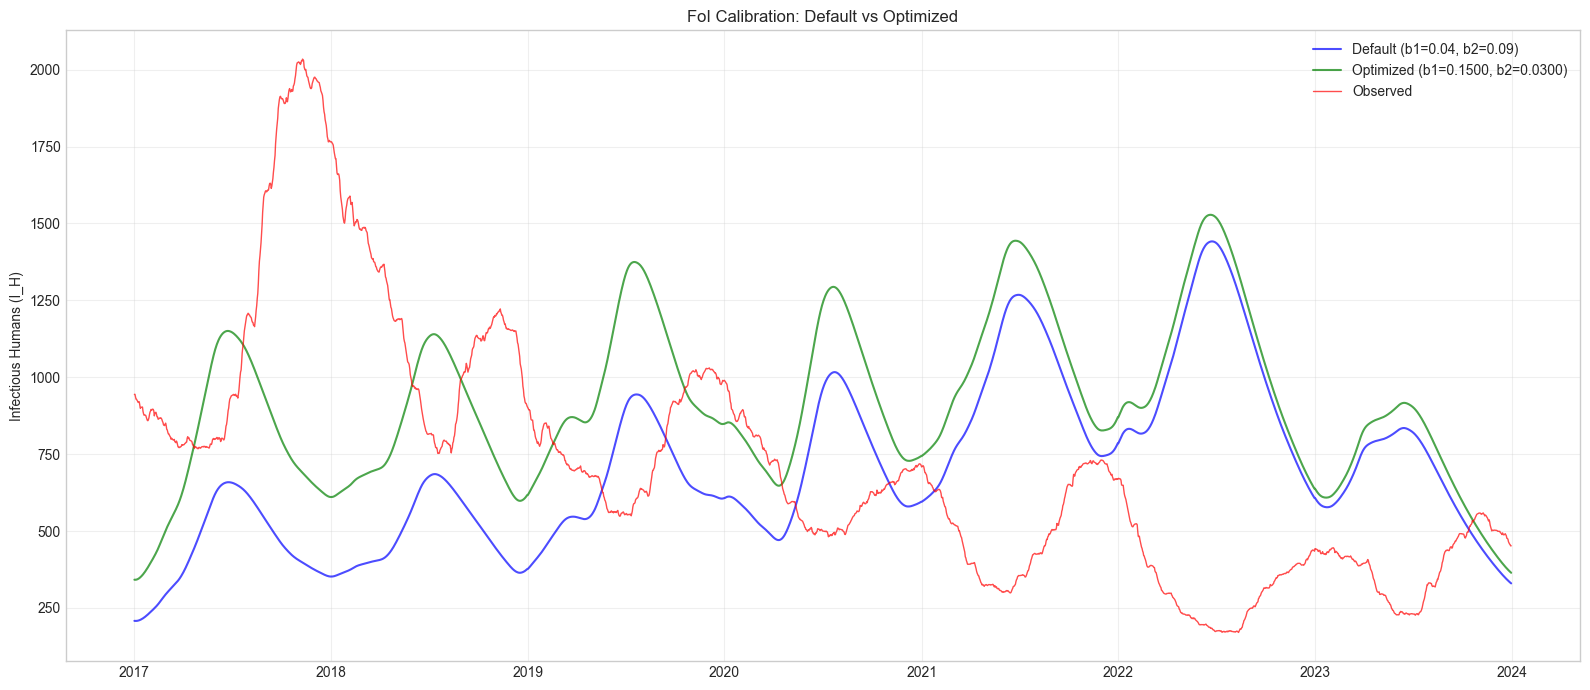

In [12]:
dates_default, IH_default = run_with_foi(b1, b2)
dates_opt, IH_opt = run_with_foi(best_params[0], best_params[1])

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(pd.to_datetime(dates_default), IH_default, 'b-', linewidth=1.5, alpha=0.7,
        label=f'Default (b1={b1}, b2={b2})')
ax.plot(pd.to_datetime(dates_opt), IH_opt, 'g-', linewidth=1.5, alpha=0.7,
        label=f'Optimized (b1={best_params[0]:.4f}, b2={best_params[1]:.4f})')
ax.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax.set_ylabel('Infectious Humans (I_H)')
ax.set_title('FoI Calibration: Default vs Optimized')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

Record the best b1 and b2 values for downstream calibrations.


In [14]:
opt_b1 = best_params[0]
opt_b2 = best_params[1]

print("=" * 55)
print("OPTIMIZED FOI PARAMETERS")
print("=" * 55)
print(f"  b1 = {opt_b1:.4f}  (human-to-mosquito transmission)")
print(f"  b2 = {opt_b2:.4f}  (mosquito-to-human transmission)")
print(f"  MSE = {best_mse:,.2f}")
print("=" * 55)


OPTIMIZED FOI PARAMETERS
  b1 = 0.1500  (human-to-mosquito transmission)
  b2 = 0.0300  (mosquito-to-human transmission)
  MSE = 355,546.32
